In [2]:
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 
import numpy as np 



from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler , OneHotEncoder , LabelEncoder
from sklearn.metrics import accuracy_score , f1_score , recall_score , classification_report , confusion_matrix 

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import AdaBoostClassifier , RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB 
from sklearn.neighbors import KNeighborsClassifier



In [3]:
df = pd.read_csv('fraud.csv')
df.head(10)

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.00,160296.36,M1979787155,0.0,0.00,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.00,19384.72,M2044282225,0.0,0.00,0,0
2,1,TRANSFER,181.00,C1305486145,181.00,0.00,C553264065,0.0,0.00,1,0
3,1,CASH_OUT,181.00,C840083671,181.00,0.00,C38997010,21182.0,0.00,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.00,29885.86,M1230701703,0.0,0.00,0,0
5,1,PAYMENT,7817.71,C90045638,53860.00,46042.29,M573487274,0.0,0.00,0,0
6,1,PAYMENT,7107.77,C154988899,183195.00,176087.23,M408069119,0.0,0.00,0,0
7,1,PAYMENT,7861.64,C1912850431,176087.23,168225.59,M633326333,0.0,0.00,0,0
8,1,PAYMENT,4024.36,C1265012928,2671.00,0.00,M1176932104,0.0,0.00,0,0
9,1,DEBIT,5337.77,C712410124,41720.00,36382.23,C195600860,41898.0,40348.79,0,0


In [4]:
df.shape

(6362620, 11)

In [5]:
df.dtypes

step                int64
type                  str
amount            float64
nameOrig              str
oldbalanceOrg     float64
newbalanceOrig    float64
nameDest              str
oldbalanceDest    float64
newbalanceDest    float64
isFraud             int64
isFlaggedFraud      int64
dtype: object

In [6]:
df.describe

<bound method NDFrame.describe of          step      type      amount     nameOrig  oldbalanceOrg  \
0           1   PAYMENT     9839.64  C1231006815      170136.00   
1           1   PAYMENT     1864.28  C1666544295       21249.00   
2           1  TRANSFER      181.00  C1305486145         181.00   
3           1  CASH_OUT      181.00   C840083671         181.00   
4           1   PAYMENT    11668.14  C2048537720       41554.00   
...       ...       ...         ...          ...            ...   
6362615   743  CASH_OUT   339682.13   C786484425      339682.13   
6362616   743  TRANSFER  6311409.28  C1529008245     6311409.28   
6362617   743  CASH_OUT  6311409.28  C1162922333     6311409.28   
6362618   743  TRANSFER   850002.52  C1685995037      850002.52   
6362619   743  CASH_OUT   850002.52  C1280323807      850002.52   

         newbalanceOrig     nameDest  oldbalanceDest  newbalanceDest  isFraud  \
0             160296.36  M1979787155            0.00            0.00        0   

In [7]:
df.columns

Index(['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig',
       'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud',
       'isFlaggedFraud'],
      dtype='str')

In [8]:
df.isnull().sum()

step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64

In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
# Features engineering 

df ['original_sender_balance'] = (
    df['oldbalanceOrg'] - df['newbalanceOrig']
)

df['original_sender_balance']


0             9839.64
1             1864.28
2              181.00
3              181.00
4            11668.14
              ...    
6362615     339682.13
6362616    6311409.28
6362617    6311409.28
6362618     850002.52
6362619     850002.52
Name: original_sender_balance, Length: 6362620, dtype: float64

In [11]:
df['Dest_reciever_balance'] = (
    df['newbalanceDest'] -  df['oldbalanceDest']
) 

df['Dest_reciever_balance']

0                0.00
1                0.00
2                0.00
3           -21182.00
4                0.00
              ...    
6362615     339682.13
6362616          0.00
6362617    6311409.27
6362618          0.00
6362619     850002.52
Name: Dest_reciever_balance, Length: 6362620, dtype: float64

In [12]:
df['ammount/old_bal'] = (
    df['amount'] / (df['oldbalanceOrg'] + 1)
) * 100


df['ammount/old_bal']

0           5.783363
1           8.773082
2          99.450549
3          99.450549
4          28.078787
             ...    
6362615    99.999706
6362616    99.999984
6362617    99.999984
6362618    99.999882
6362619    99.999882
Name: ammount/old_bal, Length: 6362620, dtype: float64

In [13]:
df

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,original_sender_balance,Dest_reciever_balance,ammount/old_bal
0,1,PAYMENT,9839.64,C1231006815,170136.00,160296.36,M1979787155,0.00,0.00,0,0,9839.64,0.00,5.783363
1,1,PAYMENT,1864.28,C1666544295,21249.00,19384.72,M2044282225,0.00,0.00,0,0,1864.28,0.00,8.773082
2,1,TRANSFER,181.00,C1305486145,181.00,0.00,C553264065,0.00,0.00,1,0,181.00,0.00,99.450549
3,1,CASH_OUT,181.00,C840083671,181.00,0.00,C38997010,21182.00,0.00,1,0,181.00,-21182.00,99.450549
4,1,PAYMENT,11668.14,C2048537720,41554.00,29885.86,M1230701703,0.00,0.00,0,0,11668.14,0.00,28.078787
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6362615,743,CASH_OUT,339682.13,C786484425,339682.13,0.00,C776919290,0.00,339682.13,1,0,339682.13,339682.13,99.999706
6362616,743,TRANSFER,6311409.28,C1529008245,6311409.28,0.00,C1881841831,0.00,0.00,1,0,6311409.28,0.00,99.999984
6362617,743,CASH_OUT,6311409.28,C1162922333,6311409.28,0.00,C1365125890,68488.84,6379898.11,1,0,6311409.28,6311409.27,99.999984
6362618,743,TRANSFER,850002.52,C1685995037,850002.52,0.00,C2080388513,0.00,0.00,1,0,850002.52,0.00,99.999882


In [14]:
encoder = OneHotEncoder(sparse_output=False, dtype=int)

In [15]:
df = df.drop(['nameOrig','nameDest'],axis=1)

In [16]:
df

,step,type,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,original_sender_balance,Dest_reciever_balance,ammount/old_bal
0,1,PAYMENT,9839.64,170136.00,160296.36,0.00,0.00,0,0,9839.64,0.00,5.783363
1,1,PAYMENT,1864.28,21249.00,19384.72,0.00,0.00,0,0,1864.28,0.00,8.773082
2,1,TRANSFER,181.00,181.00,0.00,0.00,0.00,1,0,181.00,0.00,99.450549
3,1,CASH_OUT,181.00,181.00,0.00,21182.00,0.00,1,0,181.00,-21182.00,99.450549
4,1,PAYMENT,11668.14,41554.00,29885.86,0.00,0.00,0,0,11668.14,0.00,28.078787
...,...,...,...,...,...,...,...,...,...,...,...,...
6362615,743,CASH_OUT,339682.13,339682.13,0.00,0.00,339682.13,1,0,339682.13,339682.13,99.999706
6362616,743,TRANSFER,6311409.28,6311409.28,0.00,0.00,0.00,1,0,6311409.28,0.00,99.999984
6362617,743,CASH_OUT,6311409.28,6311409.28,0.00,68488.84,6379898.11,1,0,6311409.28,6311409.27,99.999984
6362618,743,TRANSFER,850002.52,850002.52,0.00,0.00,0.00,1,0,850002.52,0.00,99.999882


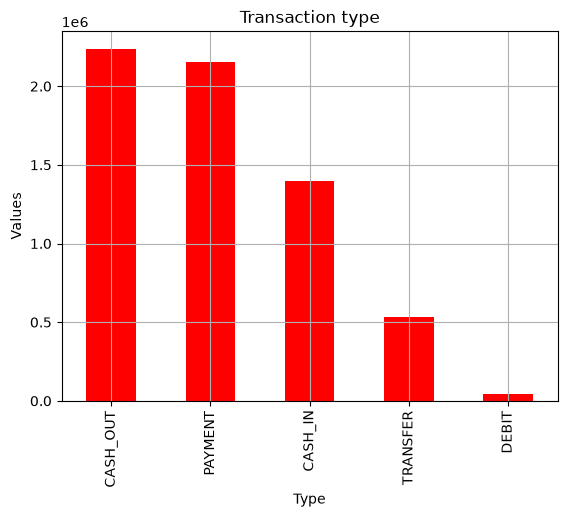

In [17]:
df['type'].value_counts().plot(kind='bar' , color='red' , title='Transaction type')
plt.xlabel('Type')
plt.ylabel('Values')
plt.grid()
plt.show()


In [18]:
df

,step,type,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,original_sender_balance,Dest_reciever_balance,ammount/old_bal
0,1,PAYMENT,9839.64,170136.00,160296.36,0.00,0.00,0,0,9839.64,0.00,5.783363
1,1,PAYMENT,1864.28,21249.00,19384.72,0.00,0.00,0,0,1864.28,0.00,8.773082
2,1,TRANSFER,181.00,181.00,0.00,0.00,0.00,1,0,181.00,0.00,99.450549
3,1,CASH_OUT,181.00,181.00,0.00,21182.00,0.00,1,0,181.00,-21182.00,99.450549
4,1,PAYMENT,11668.14,41554.00,29885.86,0.00,0.00,0,0,11668.14,0.00,28.078787
...,...,...,...,...,...,...,...,...,...,...,...,...
6362615,743,CASH_OUT,339682.13,339682.13,0.00,0.00,339682.13,1,0,339682.13,339682.13,99.999706
6362616,743,TRANSFER,6311409.28,6311409.28,0.00,0.00,0.00,1,0,6311409.28,0.00,99.999984
6362617,743,CASH_OUT,6311409.28,6311409.28,0.00,68488.84,6379898.11,1,0,6311409.28,6311409.27,99.999984
6362618,743,TRANSFER,850002.52,850002.52,0.00,0.00,0.00,1,0,850002.52,0.00,99.999882


In [19]:
df['isFraud'].value_counts()

isFraud
0    6354407
1       8213
Name: count, dtype: int64

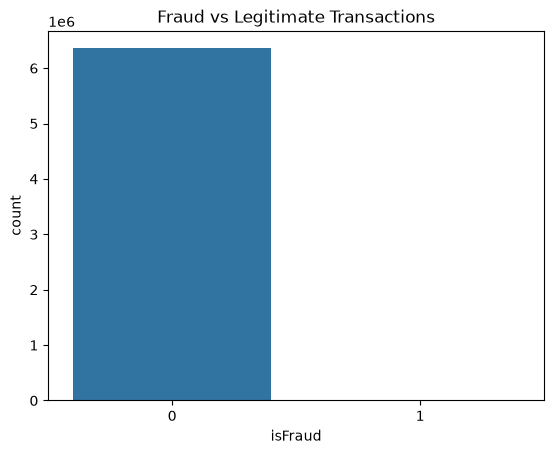

In [20]:
sns.countplot(x="isFraud", data=df)
plt.title("Fraud vs Legitimate Transactions")
plt.show()

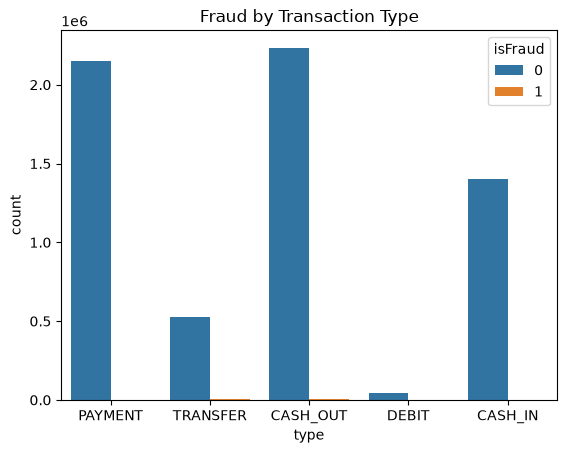

In [21]:
sns.countplot(x="type", hue="isFraud", data=df)
plt.title("Fraud by Transaction Type")
plt.show()

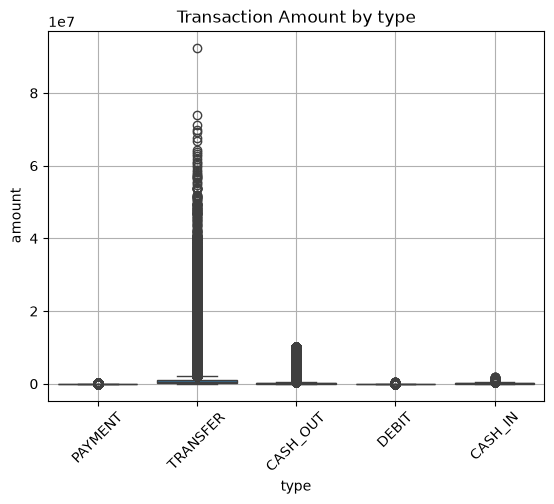

In [22]:
sns.boxplot(x='type',y='amount',data=df )
plt.title('Transaction Amount by type')
plt.xticks(rotation=45)
plt.grid()
plt.show()

In [23]:
X , y = df.drop('isFraud',axis=1) , df['isFraud']


In [24]:
encoded = encoder.fit_transform(X[['type']])

encoded_df = pd.DataFrame(
    encoded,
    columns = encoder.get_feature_names_out(['type']),
    index=X.index
)

X = pd.concat([X.drop('type',axis=1) , encoded_df],axis=1) 



In [25]:
df

,step,type,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,original_sender_balance,Dest_reciever_balance,ammount/old_bal
0,1,PAYMENT,9839.64,170136.00,160296.36,0.00,0.00,0,0,9839.64,0.00,5.783363
1,1,PAYMENT,1864.28,21249.00,19384.72,0.00,0.00,0,0,1864.28,0.00,8.773082
2,1,TRANSFER,181.00,181.00,0.00,0.00,0.00,1,0,181.00,0.00,99.450549
3,1,CASH_OUT,181.00,181.00,0.00,21182.00,0.00,1,0,181.00,-21182.00,99.450549
4,1,PAYMENT,11668.14,41554.00,29885.86,0.00,0.00,0,0,11668.14,0.00,28.078787
...,...,...,...,...,...,...,...,...,...,...,...,...
6362615,743,CASH_OUT,339682.13,339682.13,0.00,0.00,339682.13,1,0,339682.13,339682.13,99.999706
6362616,743,TRANSFER,6311409.28,6311409.28,0.00,0.00,0.00,1,0,6311409.28,0.00,99.999984
6362617,743,CASH_OUT,6311409.28,6311409.28,0.00,68488.84,6379898.11,1,0,6311409.28,6311409.27,99.999984
6362618,743,TRANSFER,850002.52,850002.52,0.00,0.00,0.00,1,0,850002.52,0.00,99.999882


In [26]:

X_train , X_test , y_train , y_test = train_test_split(
    X,y, test_size=0.2  , random_state=42 ,stratify=y
)





In [27]:
print(y_train.value_counts())

isFraud
0    5083526
1       6570
Name: count, dtype: int64


In [28]:
from imblearn.over_sampling import SMOTE

In [29]:
smote = SMOTE(
    random_state=42
)

X_train_smote , y_train_smote = smote.fit_resample(
    X_train,
    y_train
)
print(y_train.value_counts())
print(y_train_smote.value_counts())



isFraud
0    5083526
1       6570
Name: count, dtype: int64
isFraud
0    5083526
1    5083526
Name: count, dtype: int64


In [36]:
models = {
    'LogisticRegression' : LogisticRegression(max_iter=200),
    'KNeighborsClassifier':KNeighborsClassifier(n_neighbors=4),
    'GaussianNB':GaussianNB(),
  }


accuracies = {}

for name , model  in models.items():

    model.fit(X_train_smote , y_train_smote)
    prediction = model.predict(X_test)

    acc = accuracy_score(y_test,prediction)
    print(f'Accuracy score of the model is {name} : {acc*100:.1f}%')

    accuracies[name] = acc




c:\Users\Shamim Rangrej\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 200 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=200).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Accuracy score of the model is LogisticRegression : 96.0%
Accuracy score of the model is KNeighborsClassifier : 99.6%
Accuracy score of the model is GaussianNB : 94.7%


C:\Users\Shamim Rangrej\AppData\Local\Temp\ipykernel_17388\131873053.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=accuracies.keys() , y=list(accuracies.values()) , palette='viridis' )


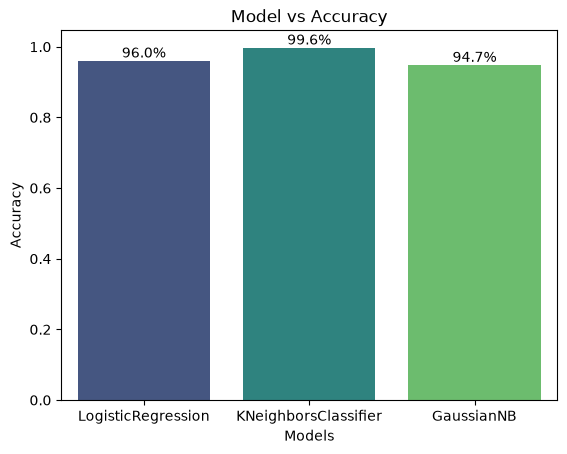

In [37]:
sns.barplot(x=accuracies.keys() , y=list(accuracies.values()) , palette='viridis' )

plt.title('Model vs Accuracy')
plt.xlabel('Models')
plt.ylabel('Accuracy')
for i, v in enumerate(accuracies.values()):
    plt.text(
        i,
        v + 0.01,
        f"{v*100:.1f}%",
        ha='center'
    )

plt.show()

In [38]:
best_model = max(accuracies , key=accuracies.get)
print(f'The best model is {best_model}')



The best model is KNeighborsClassifier


In [39]:
df.columns

Index(['step', 'type', 'amount', 'oldbalanceOrg', 'newbalanceOrig',
       'oldbalanceDest', 'newbalanceDest', 'isFraud', 'isFlaggedFraud',
       'original_sender_balance', 'Dest_reciever_balance', 'ammount/old_bal'],
      dtype='str')

In [40]:
df.head(5)

,step,type,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,original_sender_balance,Dest_reciever_balance,ammount/old_bal
0,1,PAYMENT,9839.64,170136.0,160296.36,0.0,0.0,0,0,9839.64,0.0,5.783363
1,1,PAYMENT,1864.28,21249.0,19384.72,0.0,0.0,0,0,1864.28,0.0,8.773082
2,1,TRANSFER,181.00,181.0,0.00,0.0,0.0,1,0,181.00,0.0,99.450549
3,1,CASH_OUT,181.00,181.0,0.00,21182.0,0.0,1,0,181.00,-21182.0,99.450549
4,1,PAYMENT,11668.14,41554.0,29885.86,0.0,0.0,0,0,11668.14,0.0,28.078787


In [41]:
import pandas as pd

amount = 50000
oldbalanceOrg = 60000
newbalanceOrig = 10000
oldbalanceDest = 20000
newbalanceDest = 70000

original_sender_balance = oldbalanceOrg - newbalanceOrig

Dest_reciever_balance = newbalanceDest - oldbalanceDest

ammount_old_bal = (
    amount / (oldbalanceOrg + 1)
) * 100

new_transaction = {
    "step": 100,
    "type": "TRANSFER",
    "amount": amount,
    "oldbalanceOrg": oldbalanceOrg,
    "newbalanceOrig": newbalanceOrig,
    "oldbalanceDest": oldbalanceDest,
    "newbalanceDest": newbalanceDest,
    "isFlaggedFraud": 0,
    "original_sender_balance": original_sender_balance,
    "Dest_reciever_balance": Dest_reciever_balance,
    "ammount/old_bal": ammount_old_bal
}

new_transaction_df = pd.DataFrame([new_transaction])

new_transaction_df = pd.get_dummies(
    new_transaction_df,
    columns=["type"]
)

expected_columns = model.feature_names_in_

new_transaction_df = new_transaction_df.reindex(
    columns=expected_columns,
    fill_value=0
)

prediction = model.predict(new_transaction_df)

print("Engineered Features:")
print("original_sender_balance:", original_sender_balance)
print("Dest_reciever_balance:", Dest_reciever_balance)
print("ammount/old_bal:", ammount_old_bal)

print("Prediction:", prediction)

if prediction[0] == 1:
    print("🚨 Fraudulent transaction")
else:
    print("✅ Legitimate transaction")

Engineered Features:
original_sender_balance: 50000
Dest_reciever_balance: 50000
ammount/old_bal: 83.33194446759221
Prediction: [0]
✅ Legitimate transaction


In [42]:
if prediction[0] == 1:
    print('Fraudelent transaction')
else:
    print('Legitimate transaction')

    

Legitimate transaction


In [43]:
print("Prediction:", model.predict(new_transaction_df))
print("Probability:", model.predict_proba(new_transaction_df))

Prediction: [0]
Probability: [[0.89971307 0.10028693]]


In [44]:
print(model.classes_)

[0 1]


In [45]:
probability = model.predict_proba(new_transaction_df)[0]

print("Legitimate:", probability[0] * 100, "%")
print("Fraud:", probability[1] * 100, "%")
print("Prediction:", model.predict(new_transaction_df)[0])

Legitimate: 89.97130708781906 %
Fraud: 10.028692912180384 %
Prediction: 0


In [36]:
import joblib 

In [37]:
joblib.dump(model , 'model.pkl')

['model.pkl']